In [9]:
import json
import ollama
from collections import Counter
from pathlib import Path

import pandas as pd
import plotly.express as px

SHARES_CSV = Path('../data/Complete_LinkedInDataExport_05-09-2026.zip/Shares.csv')
CACHE_DIR = Path('../cache')
MODEL = "qwen2.5:14b"

In [10]:

# Read the shares file
df = pd.read_csv(
    SHARES_CSV,
    usecols=['Date', 'SharedUrl']
)
df['Date'] = pd.to_datetime(df['Date'])
df['post_type'] = df['SharedUrl'].fillna('').str.strip().apply(
    lambda x: 'Reshared Post' if x else 'Original Post'
)
df.head()


,Date,SharedUrl,post_type
0,2026-04-22 01:43:04,NaN,Original Post
1,2026-04-21 15:44:38,NaN,Original Post
2,2026-04-19 17:04:26,NaN,Original Post
3,2026-04-13 15:58:02,NaN,Original Post
4,2026-04-10 21:05:45,NaN,Original Post


In [11]:

# Aggregate posts by month and year
COLOR_MAP = {
    'Original Post': '#0A66C2',
    'Reshared Post': '#F5A623',
}
CATEGORY_ORDER = ['Original Post', 'Reshared Post']

monthly = (
    df.assign(month=df['Date'].dt.to_period('M').apply(lambda p: p.start_time))
    .groupby(['month', 'post_type'])
    .size()
    .reset_index(name='posts')
)
monthly_totals = monthly.groupby('month')['posts'].sum()

yearly = (
    df.assign(year=df['Date'].dt.year)
    .groupby(['year', 'post_type'])
    .size()
    .reset_index(name='posts')
)
yearly_totals = yearly.groupby('year')['posts'].sum()

total = monthly['posts'].sum()

def add_total_annotations(fig, totals):
    fig.update_traces(text=None)
    for x, y in totals.items():
        fig.add_annotation(
            x=x, y=y, text=str(y),
            showarrow=False, yanchor='bottom',
            yshift=4, font=dict(size=11),
        )

fig_monthly = px.bar(
    monthly, x='month', y='posts', color='post_type',
    barmode='stack',
    title=f'LinkedIn Posts per Month (Total: {total})',
    color_discrete_map=COLOR_MAP,
    category_orders={'post_type': CATEGORY_ORDER},
)
add_total_annotations(fig_monthly, monthly_totals)
fig_monthly.update_layout(
    xaxis=dict(title='Month', tickformat='%b %Y'),
    yaxis_title='Number of Posts',
    bargap=0.2,
    legend_title='Post Type',
)
fig_monthly.show()

fig_yearly = px.bar(
    yearly, x='year', y='posts', color='post_type',
    barmode='stack',
    title='LinkedIn Posts per Year',
    color_discrete_map=COLOR_MAP,
    category_orders={'post_type': CATEGORY_ORDER},
)
add_total_annotations(fig_yearly, yearly_totals)
fig_yearly.update_layout(
    xaxis=dict(title='Year', tickmode='linear', dtick=1),
    yaxis_title='Number of Posts',
    bargap=0.2,
    legend_title='Post Type',
)
fig_yearly.show()


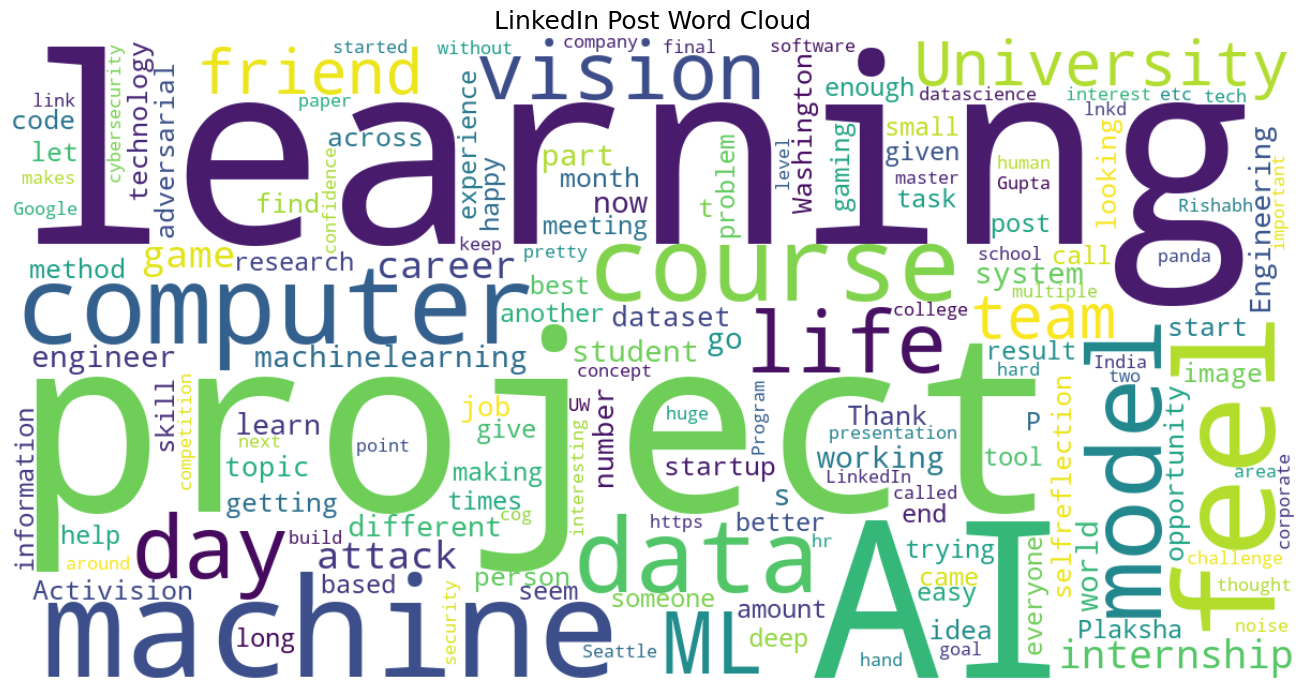

In [12]:

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

extra_stopwords = {
    'will', 'one', 'us', 'also', 'even', 'get', 'got', 'much', 'many',
    'make', 'made', 'way', 'like', 'just', 'know', 'think', 'time',
    'really', 'very', 'can', 'use', 'used', 'using', 'want', 'need',
    'people', 'good', 'great', 'new', 'work', 'well', 'still', 'lot',
    'years', 'year', 'something', 'things', 'thing', 'going', 'come',
    'see', 'look', 'take', 'first', 'last', 'may', 'would', 'could',
    'never', 'always', 'every', 'back', 'come', 'put', 'even', 'right',
}
stopwords = STOPWORDS | extra_stopwords

df_text = pd.read_csv(
    SHARES_CSV,
    usecols=['ShareCommentary']
).dropna()

text = ' '.join(df_text['ShareCommentary'].astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stopwords,
    max_words=150,
    collocations=False,
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('LinkedIn Post Word Cloud', fontsize=18)
plt.tight_layout()
plt.show()


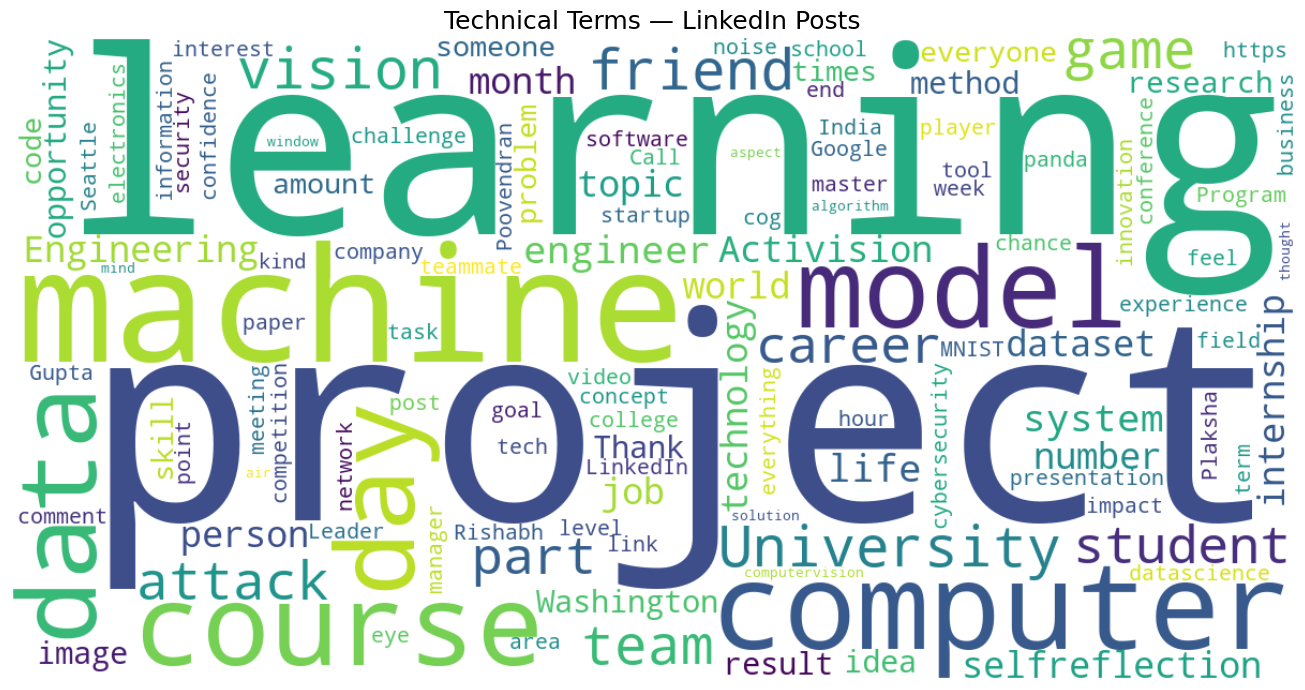

Top 20 technical terms:
  machine: 82
  learning: 79
  project: 74
  computer: 71
  data: 64
  vision: 64
  course: 64
  University: 55
  life: 55
  career: 55
  part: 51
  projects: 51
  attacks: 50
  day: 49
  selfreflection: 46
  team: 44
  person: 43
  world: 43
  game: 42
  Activision: 42


In [13]:
import nltk

nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords as nltk_stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag

common_words = set(nltk_stopwords.words('english')) | extra_stopwords | {
    'im', 'ive', 'dont', 'cant', 'its', 'thats', 'youre', 'weve',
    'heres', 'isnt', 'doesnt', 'wasnt', 'arent', 'hadnt',
}

tokens = word_tokenize(text)
tagged = pos_tag(tokens)

# Keep nouns and proper nouns (NN, NNS, NNP, NNPS) — technical terms cluster here
tech_tokens = [
    word for word, tag in tagged
    if tag in ('NN', 'NNS', 'NNP', 'NNPS')
    and word.isalpha()
    and len(word) > 2
    and word.lower() not in common_words
]

tech_freq = Counter(tech_tokens)
tech_text = ' '.join(tech_tokens)

wc_tech = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    stopwords=common_words,
    max_words=120,
    collocations=False,
).generate(tech_text)

plt.figure(figsize=(15, 7))
plt.imshow(wc_tech, interpolation='bilinear')
plt.axis('off')
plt.title('Technical Terms — LinkedIn Posts', fontsize=18)
plt.tight_layout()
plt.show()

print("Top 20 technical terms:")
for word, count in tech_freq.most_common(20):
    print(f"  {word}: {count}")

In [14]:
TOPICS = [
    "Technology & Engineering",
    "AI & Machine Learning",
    "Career & Jobs",
    "Leadership & Management",
    "Entrepreneurship & Startups",
    "Personal Development",
    "Business & Finance",
    "Education & Learning",
    "Society & Culture",
    "Gaming & Entertainment",
    "Other",
]
CACHE_FILE = CACHE_DIR / "topic_cache.json"

df_posts = pd.read_csv(
    SHARES_CSV,
    usecols=['ShareCommentary']
).dropna().reset_index(drop=True)

cache = json.loads(CACHE_FILE.read_text()) if CACHE_FILE.exists() else {}

def classify(text):
    prompt = (
        f"Classify this LinkedIn post into exactly one of these topics:\n"
        f"{', '.join(TOPICS)}\n\n"
        f"Post:\n{text[:1000]}\n\n"
        f"Reply with only the topic name, nothing else."
    )
    resp = ollama.chat(model=MODEL, messages=[{"role": "user", "content": prompt}])
    result = resp.message.content.strip()
    return result if result in TOPICS else "Other"

total = len(df_posts)
for i, row in df_posts.iterrows():
    key = str(i)
    if key not in cache:
        cache[key] = classify(row['ShareCommentary'])
        if i % 10 == 0:
            CACHE_FILE.write_text(json.dumps(cache))
            print(f"  {i}/{total} classified...")

CACHE_FILE.write_text(json.dumps(cache))
print(f"Done. {total} posts classified.")

df_posts['topic'] = [cache[str(i)] for i in range(total)]
topic_counts = df_posts['topic'].value_counts().reset_index()
topic_counts.columns = ['topic', 'count']

fig = px.bar(
    topic_counts, x='topic', y='count',
    title=f'LinkedIn Posts by Topic (Total: {total})',
    color='topic',
    text='count',
)
fig.update_layout(
    xaxis_title='Topic',
    yaxis_title='Number of Posts',
    showlegend=False,
    xaxis_tickangle=-30,
    bargap=0.2,
)
fig.update_traces(textposition='outside')
fig.show()

Done. 356 posts classified.


In [15]:
COMPANY_CACHE_FILE = CACHE_DIR / "company_cache.json"

df_orgs = pd.read_csv(
    SHARES_CSV,
    usecols=['ShareCommentary']
).dropna().reset_index(drop=True)

company_cache = json.loads(COMPANY_CACHE_FILE.read_text()) if COMPANY_CACHE_FILE.exists() else {}

def extract_companies(text):
    prompt = (
        "Extract all company and organization names mentioned in this LinkedIn post.\n"
        "Return a JSON array of strings, e.g. [\"Google\", \"OpenAI\"].\n"
        "If none found, return []. Return ONLY the JSON array, nothing else.\n\n"
        f"Post:\n{text[:1000]}"
    )
    resp = ollama.chat(model=MODEL, messages=[{"role": "user", "content": prompt}])
    raw = resp.message.content.strip()
    try:
        result = json.loads(raw)
        return result if isinstance(result, list) else []
    except json.JSONDecodeError:
        return []

total = len(df_orgs)
for i, row in df_orgs.iterrows():
    key = str(i)
    if key not in company_cache:
        company_cache[key] = extract_companies(row['ShareCommentary'])
        if i % 10 == 0:
            COMPANY_CACHE_FILE.write_text(json.dumps(company_cache))
            print(f"  {i}/{total} processed...")

COMPANY_CACHE_FILE.write_text(json.dumps(company_cache))
print(f"Done. {total} posts processed.")

org_counter = Counter()
for orgs in company_cache.values():
    for org in orgs:
        name = org.strip()
        if len(name) > 1:
            org_counter[name] += 1

top_n = 30
top_orgs = pd.DataFrame(org_counter.most_common(top_n), columns=['org', 'count'])

fig = px.bar(
    top_orgs.sort_values('count'), x='count', y='org',
    orientation='h',
    title=f'Top {top_n} Companies/Organizations Mentioned in Posts',
    text='count',
    color='count',
    color_continuous_scale='Blues',
)
fig.update_layout(
    xaxis_title='Mentions',
    yaxis_title='',
    coloraxis_showscale=False,
    height=800,
)
fig.update_traces(textposition='outside')
fig.show()

  0/356 processed...
  10/356 processed...
  20/356 processed...
  30/356 processed...
  40/356 processed...
  50/356 processed...
  60/356 processed...
  70/356 processed...
  80/356 processed...
  90/356 processed...
  100/356 processed...
  110/356 processed...
  120/356 processed...
  130/356 processed...
  140/356 processed...
  150/356 processed...
  160/356 processed...
  170/356 processed...
  180/356 processed...
  190/356 processed...
  200/356 processed...
  210/356 processed...
  220/356 processed...
  230/356 processed...
  240/356 processed...
  250/356 processed...
  260/356 processed...
  270/356 processed...
  280/356 processed...
  290/356 processed...
  300/356 processed...
  310/356 processed...
  320/356 processed...
  330/356 processed...
  340/356 processed...
  350/356 processed...
Done. 356 posts processed.
